# IPL Data Analysis Using Python

### Objective
Analyze historical IPL data to identify team performance, player statistics, and match trends using Python.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

matches.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,WinningTeam,Margin,WonBy,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,Umpire3
0,1082591,Hyderabad,2017-04-05,2017,1,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,field,Sunrisers Hyderabad,35,runs,['Yuvraj Singh'],"['DA Warner', 'S Dhawan', 'MC Henriques', 'Yuv...","['CH Gayle', 'Mandeep Singh', 'TM Head', 'KM J...",AY Dandekar,NJ Llong,A Deshmukh
1,1082592,Pune,2017-04-06,2017,2,Rising Pune Supergiant,Mumbai Indians,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,field,Rising Pune Supergiant,7,wickets,['SPD Smith'],"['AM Rahane', 'MA Agarwal', 'SPD Smith', 'BA S...","['PA Patel', 'JC Buttler', 'RG Sharma', 'N Ran...",A Nand Kishore,S Ravi,VK Sharma
2,1082593,Rajkot,2017-04-07,2017,3,Gujarat Lions,Kolkata Knight Riders,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,field,Kolkata Knight Riders,10,wickets,['CA Lynn'],"['JJ Roy', 'BB McCullum', 'SK Raina', 'AJ Finc...","['G Gambhir', 'CA Lynn', 'RV Uthappa', 'MK Pan...",Nitin Menon,CK Nandan,YC Barde
3,1082594,Indore,2017-04-08,2017,4,Kings XI Punjab,Rising Pune Supergiant,Holkar Cricket Stadium,Kings XI Punjab,field,Kings XI Punjab,6,wickets,['GJ Maxwell'],"['HM Amla', 'M Vohra', 'WP Saha', 'AR Patel', ...","['AM Rahane', 'MA Agarwal', 'SPD Smith', 'BA S...",AK Chaudhary,C Shamshuddin,KN Ananthapadmanabhan
4,1082595,Bengaluru,2017-04-08,2017,5,Royal Challengers Bangalore,Delhi Daredevils,M.Chinnaswamy Stadium,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,15,runs,['KM Jadhav'],"['CH Gayle', 'SR Watson', 'Mandeep Singh', 'KM...","['AP Tare', 'SW Billings', 'KK Nair', 'SV Sams...",S Ravi,VK Sharma,A Nand Kishore


In [4]:
#Dataset Overview
matches.info()
deliveries.info()
matches.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               1024 non-null   int64 
 1   City             973 non-null    object
 2   Date             1024 non-null   object
 3   Season           1024 non-null   object
 4   MatchNumber      1024 non-null   object
 5   Team1            1024 non-null   object
 6   Team2            1024 non-null   object
 7   Venue            1024 non-null   object
 8   TossWinner       1024 non-null   object
 9   TossDecision     1024 non-null   object
 10  WinningTeam      1024 non-null   object
 11  Margin           1024 non-null   int64 
 12  WonBy            1024 non-null   object
 13  Player_of_Match  1019 non-null   object
 14  Team1Players     1024 non-null   object
 15  Team2Players     1024 non-null   object
 16  Umpire1          1024 non-null   object
 17  Umpire2          1024 non-null   

,ID,Margin
count,1.024000e+03,1024.000000
mean,8.687579e+05,17.046875
std,3.528920e+05,21.798055
min,3.359820e+05,0.000000
25%,5.483138e+05,5.000000
50%,8.298140e+05,8.000000
75%,1.216503e+06,19.000000
max,1.370353e+06,146.000000


### Dataset Overview
The `matches` dataset contains match-level information, while the `deliveries` dataset contains ball-by-ball data.

In [7]:
#Most Successful Teams
team_wins=matches['WinningTeam'].value_counts()
team_wins.head(10)

WinningTeam
Mumbai Indians                 140
Chennai Super Kings            131
Kolkata Knight Riders          121
Royal Challengers Bangalore    116
Rajasthan Royals               104
Kings XI Punjab                 88
Sunrisers Hyderabad             80
Delhi Daredevils                67
Delhi Capitals                  42
Deccan Chargers                 30
Name: count, dtype: int64

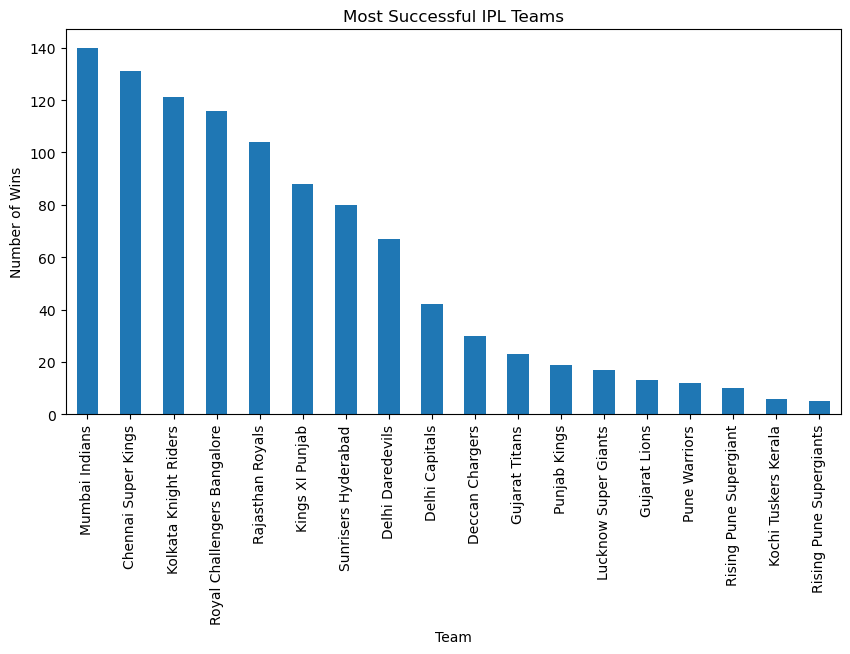

In [10]:
# Visualization 
plt.figure(figsize=(10,5))
team_wins.plot(kind='bar')
plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.show()


### Insight
The teams with the highest win counts have consistently performed well across IPL seasons.

In [12]:
# Toss Impact Analysis
toss_win_match_win=matches[matches['TossWinner']==matches['WinningTeam']]
percentage=(len(toss_win_match_win)/len(matches))*100
print("Toss win leads to match wins:",percentage,"%")

Toss win leads to match wins: 51.07421875 %


### Insight
This helps evaluate whether winning the toss significantly influences match outcomes.

In [13]:
# Top Run Scorers
top_batsmen=deliveries.groupby('Batter')['BatsmanRun'].sum().sort_values(ascending=False).head(10)
print(top_batsmen)

Batter
V Kohli           7273
S Dhawan          6617
DA Warner         6399
RG Sharma         6213
SK Raina          5536
AB de Villiers    5181
MS Dhoni          5082
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4517
Name: BatsmanRun, dtype: int64


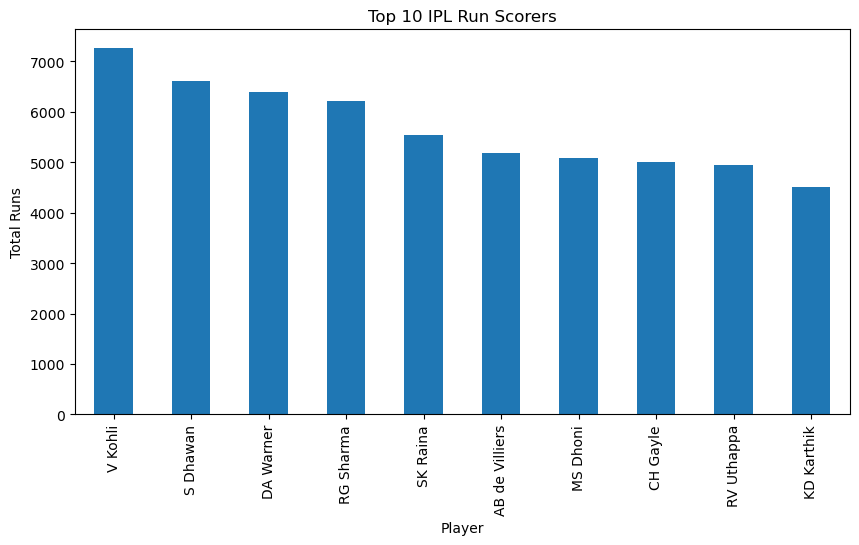

In [14]:
#Visualization
plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar')
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.show()

In [15]:
# Highest Wicket Takers
wickets=deliveries[deliveries['Kind'].notna()]
top_bowlers=wickets['Bowler'].value_counts().head(10)
print(top_bowlers)

Bowler
DJ Bravo           207
YS Chahal          194
R Ashwin           189
SL Malinga         188
PP Chawla          188
B Kumar            184
A Mishra           182
SP Narine          182
Harbhajan Singh    161
RA Jadeja          161
Name: count, dtype: int64


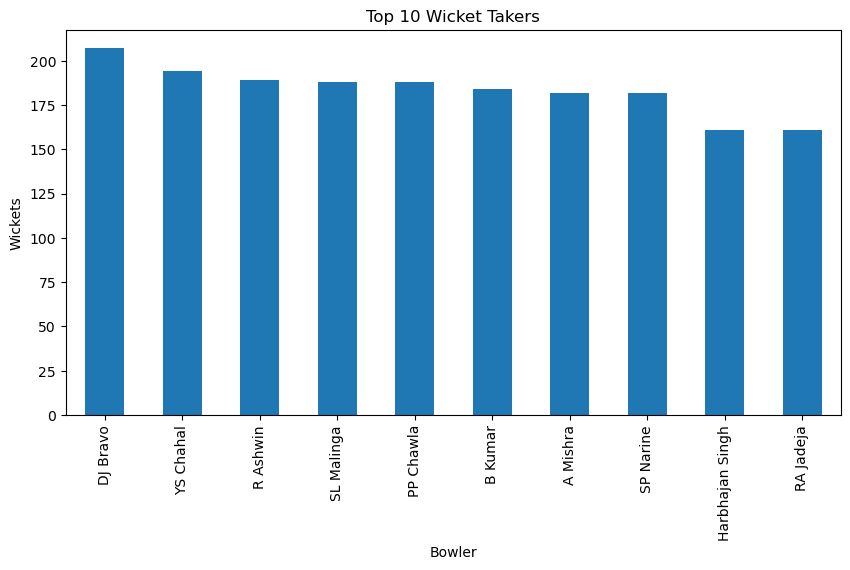

In [16]:
#Visualization
plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar')
plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()

# Key Insights

- Mumbai Indians dominate IPL with higher match wins.
- Winning the toss does not guarantee a match victory.
- Virat Kohli consistently dominate run-scoring charts.
- DJ Bravo significantly influence match outcomes.